In [ ]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [ ]:
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)

my_io_path = '/content/drive/MyDrive/'
# my_io_path = current_path+"/"
print(my_io_path)

# Utilities
IterationMonitor

In [2]:
class IterationMonitor(object):
  def __init__(self, solver):
    self.solver = solver
    self.iteration_log = []

  def update(self):
    outer_snes_its = solver.snes.getIterationNumber()   # nonlinear iterations (if SNES used)
    outer_ksp_its  = solver.snes.ksp.getIterationNumber()

    # Extract fieldsplit details
    pc = solver.snes.ksp.getPC()
    pc.setUp()

    # Get fieldsplit sub-KSPs
    subksps = pc.getFieldSplitSubKSP()

    vel_its = subksps[0].getIterationNumber()
    pres_its = subksps[1].getIterationNumber()

    # If each sub-solver has its own PC with inner iterations:
    vel_pc = subksps[0].getPC()
    pres_pc = subksps[1].getPC()

    # Optional: inner iterations of approximate Schur complement solve
    try:
        vel_inner_its = vel_pc.getKSP().getIterationNumber()
    except:
        vel_inner_its = None

    try:
        pres_inner_its = pres_pc.getKSP().getIterationNumber()
    except:
        pres_inner_its = None

    self.iteration_log.append(dict(
        step=t,
        outer_snes=outer_snes_its,
        outer_ksp=outer_ksp_its,
        vel_iters=vel_its,
        pres_iters=pres_its,
        vel_inner=vel_inner_its,
        pres_inner=pres_inner_its,
    ))


---
---
# Exercise 1 - Chorin-Temam projection method

\begin{equation*}
\begin{cases}
\frac{\partial  \boldsymbol{u}}{\partial t}- \Delta \boldsymbol{u} + ( \boldsymbol{u}\cdot \nabla)  \boldsymbol{u}+ \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, t\in(0,T),\\
\nabla \cdot \boldsymbol{u} = 0 & {\rm in} \ \Omega, t\in(0,T), \\
\boldsymbol{u} = \boldsymbol{u}_\text{in} & {\rm on} \ \Gamma_{\rm{in}}, t\in(0,T),\\
\sigma(\boldsymbol{u},p)\boldsymbol{n} = h_\text{out}\boldsymbol{n} & {\rm on} \ \Gamma_{\rm{out}}, t\in(0,T), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus(\Gamma_\text{in}\cup\Gamma_\text{out}), t\in(0,T),\\
\boldsymbol{u}|_{t=0} = \boldsymbol{u}_\text{Stokes} & {\rm in} \ \Omega, t=0
\end{cases}
\end{equation*}

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (5,) is empty. This is likely an error. Did you choose the right label?


[2896, 8418, 5522]


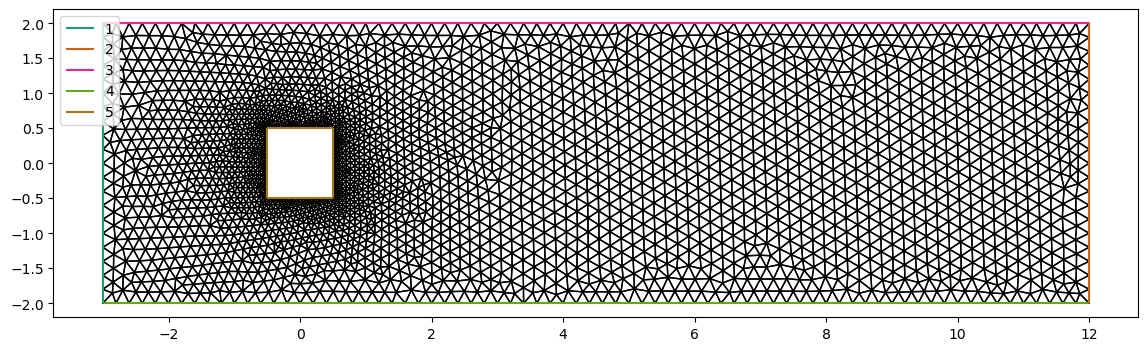

In [3]:
# Import mesh: set the path correctly!
mesh = Mesh('mesh/squareCyl.msh')
fig, ax = plt.subplots(figsize=(14, 4))
triplot(mesh, axes=ax)
ax.legend(loc='upper left')
print([mesh.size(d) for d in range(3)])

### FE spaces, data, BCs

In [13]:
# Function spaces (MixedFunctionSpace for monolithic form)
# The bubble enrichment of the velocity space has to be done at the finite element level: see Lab02.
V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
V = FunctionSpace(mesh, V_el)
# V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])
print('Dimensions  -  V :', V.dim(), ', Q :', Q.dim(), ', W :', W.dim())

# Data
Re = 20
f = Constant((0., 0.))
t = 0
T = 4.0
dt = 0.01

x = SpatialCoordinate(mesh)

# Boundary conditions on mixed space
u_in = as_vector((3.0/8.0*(2-x[1])*(2+x[1]), 0.))
bc_in = DirichletBC(W.sub(0), u_in, 1)
bc_wall = DirichletBC(W.sub(0), Constant((0.,0.)), 5)
bc_freeslip = DirichletBC(W.sub(0).sub(1), Constant(0.), (3,4))
bcs = (bc_in, bc_wall, bc_freeslip)

Dimensions  -  V : 16836 , Q : 2896 , W : 19732


### Variational forms for incremental Chorin-Temam steps

In [14]:
# Forms for monolithic problem - backward Euler with semi-implicit advection - pressure-incremental form
def monolithic_forms(u, v, dp, q, Re, dt, u_in, u_old, p_old):
    a = Constant(1.0/dt) * inner(u, v) * dx + inner(dot(grad(u), u_old), v) * dx + 2.0/Re*inner(sym(grad(u)), sym(grad(v))) * dx \
        - div(v) * dp * dx + div(u)* q * dx
    L = Constant(1.0/dt) * inner(u_old, v) * dx - inner(grad(p_old), v) * dx
    return a, L

# Forms for incremental predictor problem (u_old = u^n   ->   du tilde)
def predictor_forms(du, v, Re, dt, u_in, u_old, p_old):
    a = Constant(1.0/dt) * inner(du, v) * dx + inner(dot(grad(du), u_old), v) * dx + 2.0/Re*inner(sym(grad(du)), sym(grad(v))) * dx
    L = - inner(dot(grad(u_old), u_old), v_pred) * dx - 2.0/Re*inner(sym(grad(u_old)), sym(grad(v_pred))) * dx - inner(grad(p_old), v) * dx
    return a, L

# Forms for approximated system "C-T style" (incremental form: sol. = du, dp)
def monolithic_CT_forms(du, v, dp, q, Re, dt, u_in, u_tilde, u_old, p_old):
    a = Constant(1.0/dt) * inner(du, v) * dx \
        - div(v) * dp * dx + div(du)* q * dx
    L = Constant(1.0/dt) * inner(u_tilde, v) * dx - div(u_old)*q*dx
    return a, L

### Initial condition

In [17]:
uu, pp = TrialFunctions(W)
vv, qq = TestFunctions(W)

# Stokes problem
a_init = 2.0/Re * inner(sym(grad(uu)), sym(grad(vv))) * dx - pp * div(vv) * dx + qq * div(uu) * dx
normal = FacetNormal(mesh)
L_init = inner(f, vv) * dx
bc_in_init = DirichletBC(W.sub(0), u_in, 1)
bc_obs_init = DirichletBC(W.sub(0), Constant((0.,0.)), 5)
bc_wall_init = DirichletBC(W.sub(0).sub(1), Constant(0.), (3,4))
bcs_init = (bc_in_init, bc_wall_init, bc_obs_init)

wh_init = Function(W)
solve(a_init == L_init, wh_init, bcs=bcs_init)
uh_init, ph_init = wh_init.subfunctions

# Functions on separate spaces: assignment works anyhow.
uh_old = Function(V)
ph_old = Function(Q)
uh_old.assign(uh_init)
ph_old.assign(ph_init)

Coefficient(WithGeometry(FunctionSpace(<firedrake.mesh.MeshTopology object at 0x7c761f887da0>, FiniteElement('Lagrange', triangle, 1), name=None), Mesh(VectorElement(FiniteElement('Lagrange', triangle, 1), dim=2), 1)), 228)

### Post-processing

NameError: name 'File' is not defined

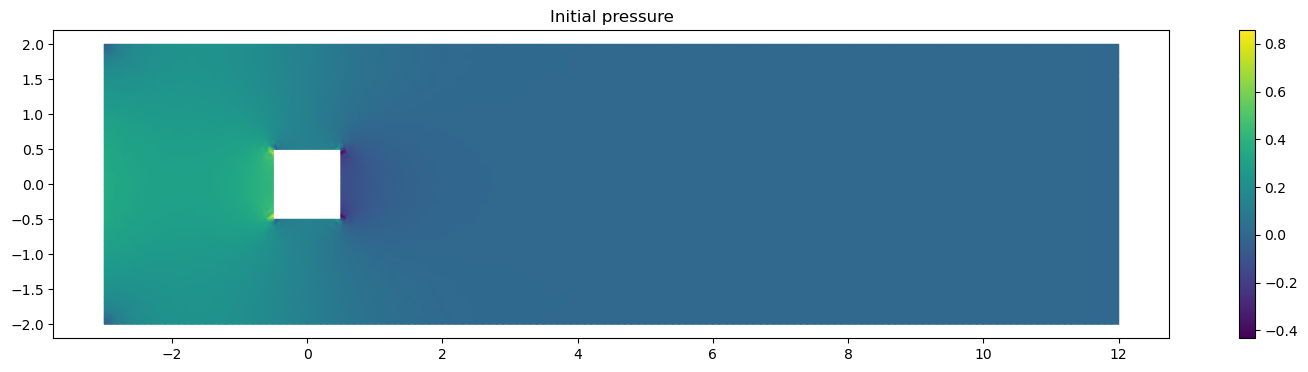

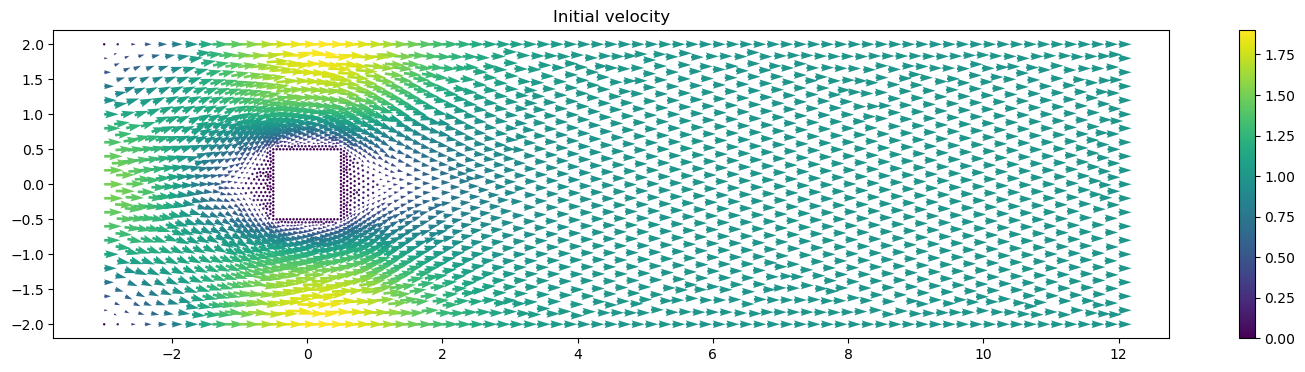

In [18]:
fig, ax = plt.subplots(figsize=(18, 4))
col = tripcolor(ph_old, axes=ax)
plt.colorbar(col)
plt.title('Initial pressure')

fig, ax = plt.subplots(figsize=(18, 4))
col = quiver(uh_old, axes=ax)
plt.colorbar(col)
plt.title('Initial velocity')

# vtk output for Paraview
basename = 'lab10_'
outfileU = File(my_io_path+"output/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"output/"+basename+"pressure.pvd")
uh_old.rename("Velocity")   # this names will be used in Paraview
ph_old.rename("Pressure")
outfileU.write(uh_old)
outfileP.write(ph_old)

### Definition of factorized algebraic system

In [19]:
du_pred = TrialFunction(V)  # incremental already in the predictor step
v_pred = TestFunction(V)
du, dp = TrialFunctions(W)  # incremental in both u and p
v, q = TestFunctions(W)

# Solution variables: for the predictor problem and then for the rest
du_tilde = Function(V)      # solution of the predictor step
wh = Function(W)            # solution of the remaining steps
duh, dph = wh.subfunctions  # incremental in both u and p

# trick for algebraic Chorin-Temam in Firedrake: predictor first, then the rest
a_pred, L_pred = predictor_forms(du_pred, v_pred, Re, dt, u_in, uh_old, ph_old)
bc_in_ZERO_pred = DirichletBC(V, Constant((0.,0.)), 1)      # homogeneous: incremental in u
bc_obs_pred = DirichletBC(V, Constant((0.,0.)), 5)
bc_wall_pred = DirichletBC(V.sub(1), Constant(0.), (3,4))
bcs_ZERO_pred = (bc_in_ZERO_pred, bc_obs_pred, bc_wall_pred)
pb_pred = LinearVariationalProblem(a_pred, L_pred, du_tilde, bcs=bcs_ZERO_pred)

a_CT, L_CT = monolithic_CT_forms(du, v, dp, q, Re, dt, u_in, du_tilde, uh_old, ph_old)
pb_CT = LinearVariationalProblem(a_CT, L_CT, wh)

# actual non-homogeneous conditions (used afterwards)
bc_in_pred = DirichletBC(V, u_in, 1)
bcs_pred = (bc_in_pred, bc_obs_pred, bc_wall_pred)

## Reminder: parameters to exploit LDU factorization


In [20]:
# Solver parameters: extracting factorization
param = {'ksp_type': 'preonly' # applying the preconditioner once corresponds to solve the system associated to it
         , 'pc_type': 'fieldsplit'   # exploit block structure
         , 'pc_fieldsplit_type': 'schur' # LU factorization type that is based on the computation of the Schur complement
         , 'pc_fieldsplit_schur_fact_type': 'full'  # full/additive/multiplicative
         # Then, for each of the two diagonal block, we need to choose a solver to "invert" them
         , 'fieldsplit_0_ksp_type': 'preonly'                                   # direct solver for matrix C^{n+1}
        #  , 'fieldsplit_0_ksp_type': 'gmres',  'fieldsplit_0_ksp_rtol': 1e-10  # iterative solver for matrix C^{n+1}
         , 'fieldsplit_0_pc_type': 'lu'                                         # preconditioner (if iterative) / solver (if preonly) for matrix C^{n+1}
         , 'fieldsplit_1_ksp_type': 'preonly', 'fieldsplit_1_pc_type': 'lu'     # iterative solver for matrix S^{n+1}
}

print(param)

# solver = LinearVariationalSolver(pb, solver_parameters=param)

{'ksp_type': 'preonly', 'pc_type': 'fieldsplit', 'pc_fieldsplit_type': 'schur', 'pc_fieldsplit_schur_fact_type': 'full', 'fieldsplit_0_ksp_type': 'preonly', 'fieldsplit_0_pc_type': 'lu', 'fieldsplit_1_ksp_type': 'preonly', 'fieldsplit_1_pc_type': 'lu'}


# Algebraic solver of Chorin-Temam type - predictor separated from the rest

In [ ]:
# Predictor step
solver_pred = LinearVariationalSolver(pb_pred, solver_parameters={
    'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'
})

# Chorin-Temam (after the predictor step, which is managed by solver_pred)
param = {'':''
        , 'ksp_type': 'preonly'
        , 'ksp_rtol': 1e-6
        , 'pc_type': 'fieldsplit'   # exploit block structure
        , 'pc_fieldsplit_type': 'schur' # LU factorization type that is based on the computation of the Schur complement
        , 'pc_fieldsplit_schur_fact_type': 'full'
        # PARAMETERS TO "INVERT" VEL-VEL BLOCK. BEWARE: THEY ARE USED ALSO TO ASSEMBLE S
        , 'fieldsplit_0_ksp_type': 'preonly'    # direct solver for matrix A00
        , 'fieldsplit_0_pc_type': 'lu', 'fieldsplit_0_pc_factor_mat_solver_type': 'mumps'
        # PARAMETERS TO "INVERT" APPROXIMATE SCHUR COMPLEMENT USING diag(A00)
        , 'pc_fieldsplit_schur_precondition': 'selfp'    # assemble S as S=A11-A10*inv(diag(A00))*A01=-B*inv(diag(M))*B^T : thanks to diag, inv is actually assembled!
        , "fieldsplit_1_ksp_type": "preonly"    # solver for S (direct solver allowed because of selfp)
        , "fieldsplit_1_pc_type": "lu", 'fieldsplit_1_pc_factor_mat_solver_type': 'mumps'  # preconditioner for S
        # PARAMETERS TO "INVERT" ACTUAL SCHUR COMPLEMENT (VERY EXPENSIVE)
        # , 'pc_fieldsplit_schur_precondition': 'full'    # define S (without actually computing inv(M)) as S=A11-A10*inv(A00)*A01=-B*inv(M)*B^T
        # , "fieldsplit_1_ksp_type": "gmres"    # solver for S (direct solver not allowed: there is inv(M) is NOT assembled)
        # , "fieldsplit_1_pc_type": "lu"
}

# Other parameters to inspect the settings and behavior of the solver
param.update({'':'' # dummy param to allow commenting/uncommenting the following lines
    # , "ksp_monitor_true_residual": None
    , "ksp_converged_reason": None
    # # , "ksp_view": None
    # # , "fieldsplit_1_inner_ksp_view": None
    # , "fieldsplit_0_ksp_converged_reason": None
    # , "fieldsplit_0_ksp_monitor_true_residual": None
    # , "fieldsplit_1_ksp_converged_reason": None
    # , "fieldsplit_1_ksp_monitor_true_residual": None
    # , "fieldsplit_1_inner_ksp_converged_reason": None
    # , "fieldsplit_1_inner_ksp_monitor_true_residual": None
})

# Construction of the solver.
solver = LinearVariationalSolver(pb_CT, solver_parameters=param)

iteration_monitor = IterationMonitor(solver) # to collect info on solver

# Function solving 1 time step:
# - before the call: uh_old, ph_old contain the solution at the previous time step t^n
# - during the call: uh_old, ph_old, du_tilde and possibly other variables change, as long as they are correctly linked together
# - after the call: uh_old, ph_old contain the solution at the previous time step t^{n+1}
def solve_1_timestep():
    solver_pred.solve()
    solver.solve()

    # Update old solution - BEWARE: incremental!
    uh_old.dat += duh.dat
    ph_old.dat += dph.dat

    # Re-assign BCs to uh_old to contain machine error accumulation that would spoil BCs
    for bc in bcs_pred:
      bc.apply(uh_old)


### Time-dependent solution

In [27]:
# Initialization (already done above, but re-introducing it here makes the notebook more robust w.r.t. running cells in a different order... as done below for SIMPLE)
wh.assign(0)
du_tilde.assign(0)
uh_old.assign(uh_init)
ph_old.assign(ph_init)

t_vec = np.arange(0, T+0.1*dt, dt)  # T+0.1*dt to include also T: range/arange exclude the upper bound of the range
iters = [solver.snes.ksp]
for ii in range(1, len(t_vec)):     # start from 1 to skip t=0
    t = t_vec[ii]
    print('------------------------------\n t =', t, '\n------------------------------')
    print('------ ||u||_{H^1} =', norm(uh_old,'H1'), '  ||p||_{L^2} =', norm(ph_old,'L2')) # to check the solution is not blowing up

    solve_1_timestep()

    print('------ # iter block linear solver = ', solver.snes.ksp.getIterationNumber(), flush=True)

    iteration_monitor.update()

    # Post-processing
    # outfileU.write(uh_old, time=t)
    # outfileP.write(ph_old, time=t)

------------------------------
 t = 0.01 
------------------------------
------ ||u||_{H^1} = 9.498633156400926   ||p||_{L^2} = 0.8837185479968951
        Linear firedrake_8_ solve converged due to CONVERGED_ITS iterations 1
------ # iter block linear solver =  1
------------------------------
 t = 0.02 
------------------------------
------ ||u||_{H^1} = 9.499595322367089   ||p||_{L^2} = 1.0570737985471446
        Linear firedrake_8_ solve converged due to CONVERGED_ITS iterations 1
------ # iter block linear solver =  1
------------------------------
 t = 0.03 
------------------------------
------ ||u||_{H^1} = 9.501691864890255   ||p||_{L^2} = 1.368697393728561
        Linear firedrake_8_ solve converged due to CONVERGED_ITS iterations 1
------ # iter block linear solver =  1
------------------------------
 t = 0.04 
------------------------------
------ ||u||_{H^1} = 9.505005247655902   ||p||_{L^2} = 1.4836132092885754
        Linear firedrake_8_ solve converged due to CONVERGED_I

(np.float64(-3.75), np.float64(12.75), np.float64(-2.2), np.float64(2.2))

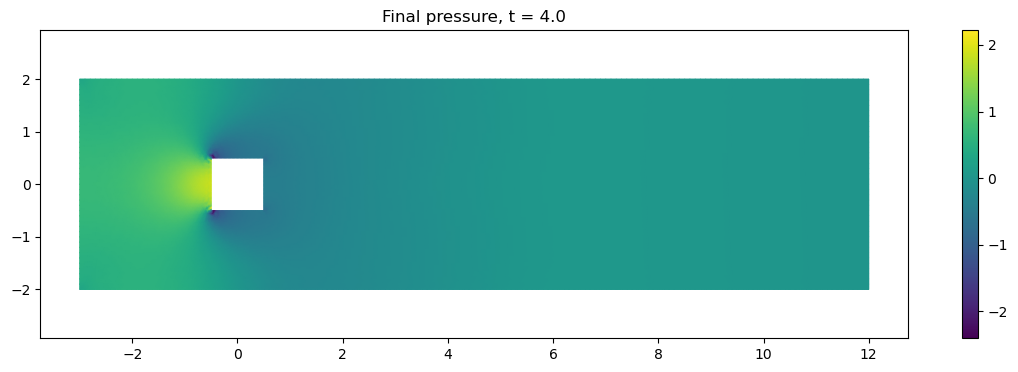

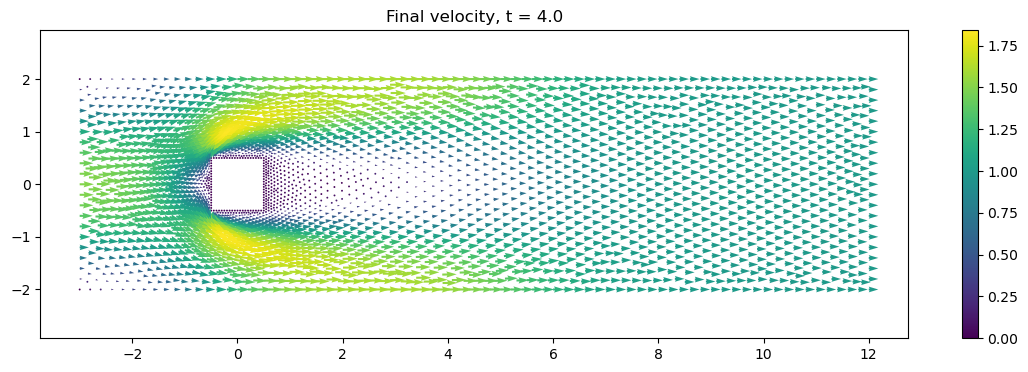

In [28]:
fig, ax = plt.subplots(figsize=(14, 4))
col = tripcolor(ph_old, axes=ax)
plt.colorbar(col)
plt.title(f'Final pressure, t = {t}')
ax.axis('equal')

fig, ax = plt.subplots(figsize=(14, 4))
col = quiver(uh_old, axes=ax)
plt.colorbar(col)
plt.title(f'Final velocity, t = {t}')
ax.axis('equal')

{'step': np.float64(0.01), 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}
{'step': np.float64(0.02), 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}


<Figure size 1000x400 with 0 Axes>

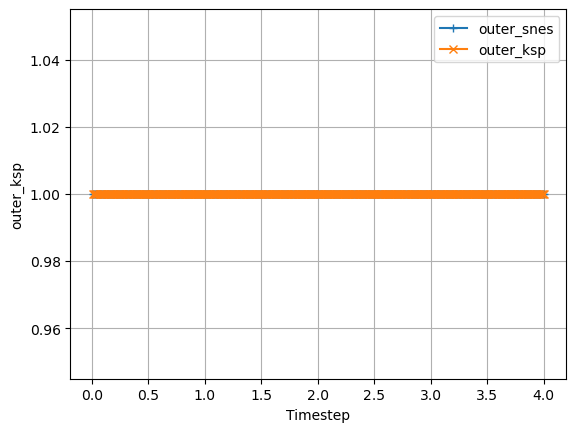

{'step': np.float64(0.01), 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}
{'step': np.float64(0.02), 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}


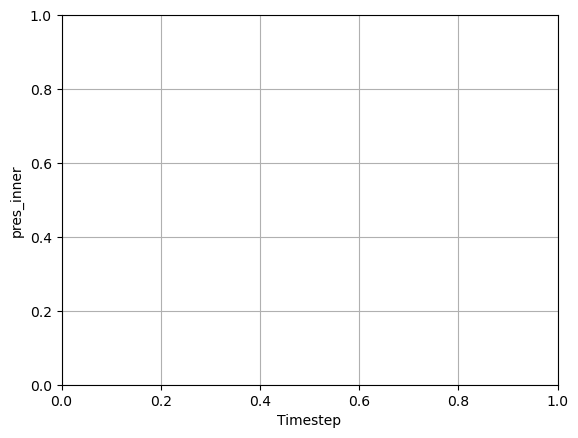

{'step': np.float64(0.01), 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}


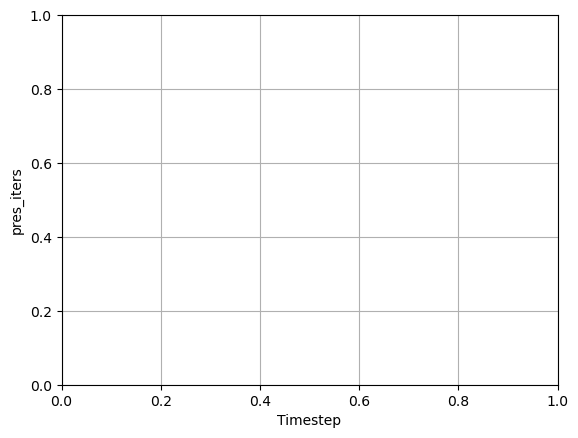

In [29]:
steps = [d["step"] for d in iteration_monitor.iteration_log]

# for s in ['outer', 'inner']:
fig = plt.figure(layout='constrained', figsize=(10, 4))
subfigs = fig.subfigures(1, 2, wspace=0.07)
subfig, ax = plt.subplots()
m = ['+','x','o']
for s in ['outer','inner','pres_iters']:
  for idx, k in enumerate([kk for kk in iteration_monitor.iteration_log[0].keys() if s in kk]):
    # plt.figure(figsize=(8,4))
    ax.plot(steps, [d[k] for d in iteration_monitor.iteration_log], marker=m[idx], label=k)
    plt.xlabel("Timestep")
    plt.ylabel(k)#"Outer KSP Iterations")
    # plt.title("Iteration Count vs Timestep")
    plt.grid(True)
    print(iteration_monitor.iteration_log[idx])
  ax.legend()#loc='upper left')
  plt.show()